# BreaScope AI: Bayesian Deep Learning for Breast Cancer Detection

This project develops a deep learning classifier to distinguish between benign and malignant breast cancer cases using the Breast Cancer Wisconsin Diagnostic Dataset. The model incorporates Monte-Carlo Dropout to estimate prediction uncertainty as a Bayesian approximation.

This work is produced purely for educational and research purposes and must not be used for clinical diagnosis.



## 1. Import Required Libraries

In this section, the relevant Python libraries for data manipulation, visualisation, machine learning, and deep learning are imported. The key libraries used are:

- **pandas / numpy** — for loading and processing tabular data  
- **matplotlib / seaborn** — for data visualisation  
- **scikit-learn** — for preprocessing, model utilities, and evaluation  
- **imbalanced-learn** — to handle class imbalance through oversampling  
- **PyTorch** — to implement and train the Convolutional Neural Network  

These libraries together support the full machine learning pipeline from dataset loading to deployment-ready model training.

In [92]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, roc_auc_score, roc_curve, classification_report
from imblearn.over_sampling import SMOTE
import joblib

### Reflection

Selecting appropriate tools at the beginning of the project ensured that the workflow could remain consistent from end to end. Using widely adopted scientific libraries also supports reproducibility and transparency, which is particularly important when working with sensitive healthcare-related data.

## 2. Load Dataset

The Breast Cancer Wisconsin Diagnostic dataset is loaded from CSV. An unnecessary index column generated during export is removed, and the target variable is mapped to numeric format:

- **0 = Benign**
- **1 = Malignant**

This ensures the data is in a suitable structure for modelling.

In [95]:
df = pd.read_csv("brca.csv")
df = df.drop(columns=['Unnamed: 0'], errors='ignore')
df.head()

,x.radius_mean,x.texture_mean,x.perimeter_mean,x.area_mean,x.smoothness_mean,x.compactness_mean,x.concavity_mean,x.concave_pts_mean,x.symmetry_mean,x.fractal_dim_mean,...,x.texture_worst,x.perimeter_worst,x.area_worst,x.smoothness_worst,x.compactness_worst,x.concavity_worst,x.concave_pts_worst,x.symmetry_worst,x.fractal_dim_worst,y
0,13.540,14.36,87.46,566.3,0.09779,0.08129,0.06664,0.047810,0.1885,0.05766,...,19.26,99.70,711.2,0.14400,0.17730,0.23900,0.12880,0.2977,0.07259,B
1,13.080,15.71,85.63,520.0,0.10750,0.12700,0.04568,0.031100,0.1967,0.06811,...,20.49,96.09,630.5,0.13120,0.27760,0.18900,0.07283,0.3184,0.08183,B
2,9.504,12.44,60.34,273.9,0.10240,0.06492,0.02956,0.020760,0.1815,0.06905,...,15.66,65.13,314.9,0.13240,0.11480,0.08867,0.06227,0.2450,0.07773,B
3,13.030,18.42,82.61,523.8,0.08983,0.03766,0.02562,0.029230,0.1467,0.05863,...,22.81,84.46,545.9,0.09701,0.04619,0.04833,0.05013,0.1987,0.06169,B
4,8.196,16.84,51.71,201.9,0.08600,0.05943,0.01588,0.005917,0.1769,0.06503,...,21.96,57.26,242.2,0.12970,0.13570,0.06880,0.02564,0.3105,0.07409,B


The dataset is from https://www.kaggle.com/datasets/utkarshx27/breast-cancer-wisconsin-diagnostic-dataset

### Reflection

At this stage the main priority was to ensure that the dataset was clean and machine-readable before any modelling took place. Converting the target labels into numeric form allows them to be used directly by the neural network. Checking the distribution of the two classes early also highlighted the presence of class imbalance, which later informed the decision to apply oversampling. Completing these steps first reduced the risk of subtle data issues affecting the model later in the pipeline.

In [98]:
df['y'].value_counts()

y
B    357
M    212
Name: count, dtype: int64

### Class Label Encoding

Before modelling, the diagnosis column is converted from text labels into numeric values so that it can be used by the neural network:

- B → 0 (Benign)
- M → 1 (Malignant)

The class counts are printed before and after conversion to confirm that no values were lost or altered during encoding.

In [100]:
df['y'] = df['y'].map({'B': 0, 'M': 1})

In [101]:
df['y'].value_counts()

y
0    357
1    212
Name: count, dtype: int64

### Reflection

Checking the label distribution at this stage confirmed that the dataset is imbalanced, with more benign than malignant cases. Identifying this early helped justify the later decision to apply oversampling, reducing the risk of the model becoming biased toward the majority class.

### Preparing Features and Target Variables

For clarity, the target column is renamed to `diagnosis`. The dataset is then split into:

- **X** — the 30 numerical diagnostic features  
- **y** — the diagnosis label (0 = benign, 1 = malignant)

The shape check confirms that there are 569 samples and 30 features, with one label per observation. This structure is required before proceeding to exploratory data analysis and model training.

In [104]:
df = df.rename(columns={'y': 'diagnosis'})

In [105]:
X = df.drop(columns=['diagnosis'])
y = df['diagnosis']

In [106]:
X.shape, y.shape

((569, 30), (569,))

### Reflection

Separating the features from the target at this stage helped keep the workflow organised and reduced the risk of accidentally using the label during preprocessing steps that should only apply to the input data.

## 3. Exploratory Data Analysis (EDA)

Before building the deep learning model, it is important to understand the dataset. The following checks are carried out:

- Inspect dataset structure and feature types  
- Review descriptive statistics such as mean, standard deviation and range  
- Confirm that there are no missing values  

These steps help validate that the dataset is clean and suitable for model training.

In [109]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   x.radius_mean        569 non-null    float64
 1   x.texture_mean       569 non-null    float64
 2   x.perimeter_mean     569 non-null    float64
 3   x.area_mean          569 non-null    float64
 4   x.smoothness_mean    569 non-null    float64
 5   x.compactness_mean   569 non-null    float64
 6   x.concavity_mean     569 non-null    float64
 7   x.concave_pts_mean   569 non-null    float64
 8   x.symmetry_mean      569 non-null    float64
 9   x.fractal_dim_mean   569 non-null    float64
 10  x.radius_se          569 non-null    float64
 11  x.texture_se         569 non-null    float64
 12  x.perimeter_se       569 non-null    float64
 13  x.area_se            569 non-null    float64
 14  x.smoothness_se      569 non-null    float64
 15  x.compactness_se     569 non-null    flo

### Reflection

The dataset contains 569 rows and 30 numerical features, with no missing values. This reduces the need for data cleaning and allows the project to focus on feature scaling, class imbalance and deep learning model design rather than data repair.

In [111]:
df.describe()

,x.radius_mean,x.texture_mean,x.perimeter_mean,x.area_mean,x.smoothness_mean,x.compactness_mean,x.concavity_mean,x.concave_pts_mean,x.symmetry_mean,x.fractal_dim_mean,...,x.texture_worst,x.perimeter_worst,x.area_worst,x.smoothness_worst,x.compactness_worst,x.concavity_worst,x.concave_pts_worst,x.symmetry_worst,x.fractal_dim_worst,diagnosis
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,0.372583
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,0.483918
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,0.000000
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,0.000000
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,0.000000
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,1.000000
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,1.000000


### Summary Statistics

Descriptive statistics are inspected to better understand the spread and range of each variable. The features operate on very different numeric scales, which supports the later decision to apply standardisation before training the neural network.

## 3.1 Class Distribution

The dataset contains two classes:

- Benign (0)
- Malignant (1)

The class distribution is plotted to check for imbalance. Some level of imbalance exists, which means the model may otherwise become biased towards predicting the majority class. This motivates the use of oversampling techniques, applied later during preprocessing.

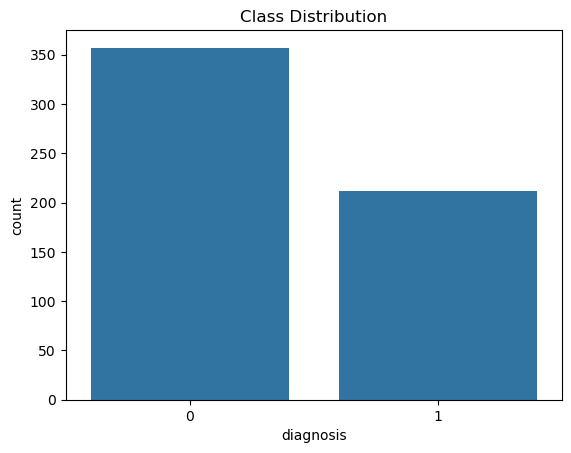

In [114]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x=df['diagnosis'])
plt.title("Class Distribution")
plt.show()

In [115]:
df.isnull().sum().sum()

0

The check for missing values confirms that none are present in the dataset.

## 3.2 Feature Correlation Heatmap

A correlation heatmap is generated to visualise relationships between input features.  
Strong correlations indicate redundancy, while weak correlations show more independent behaviour.  

Understanding these relationships helps explain why deep learning models may identify feature interactions automatically.

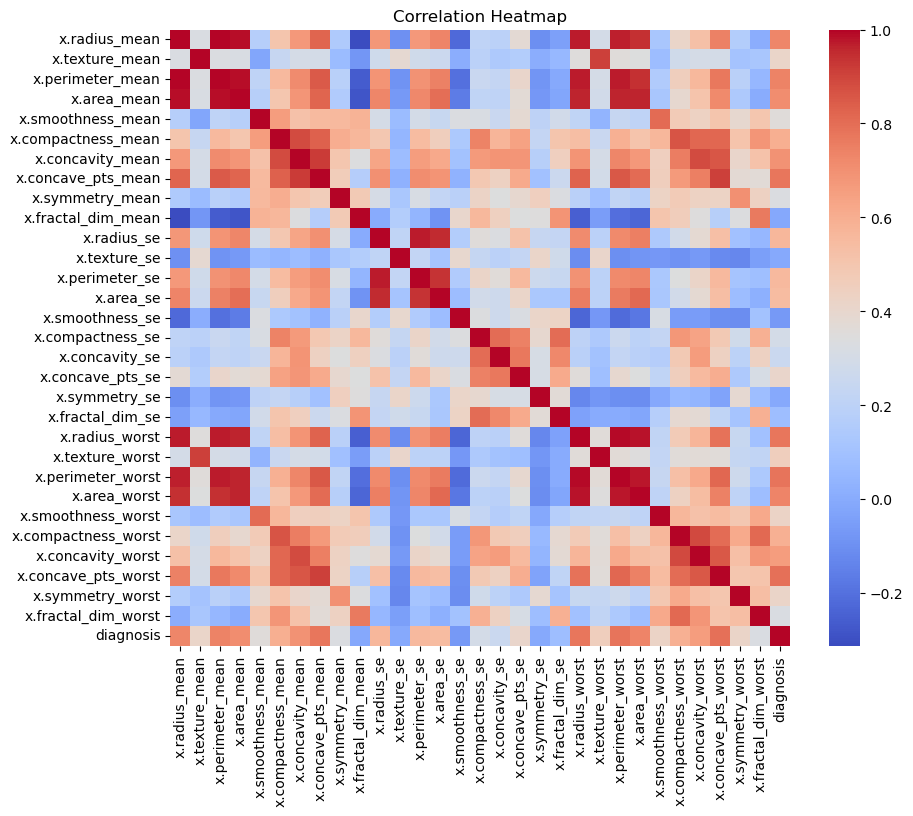

In [118]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

### Reflection

Several features show strong positive correlations (for example, radius, perimeter and area measurements). This suggests that the dataset contains groups of related diagnostic indicators rather than completely independent variables. A deep learning model is well-suited to learning these multi-feature patterns without requiring manual feature engineering.

### 3.3 Feature Distribution (Histograms & KDE)

To better understand the distribution of each numerical variable, histograms with Kernel Density Estimates (KDE) were plotted. This helps identify skewed features, multi-modal behaviour, and whether features approximately follow a Gaussian distribution (useful when applying Standard Scaling).

Many features appear right-skewed, which is expected for biological measurements such as tumour area or perimeter. This supports the decision to apply Z-score standardisation before training the deep learning model.

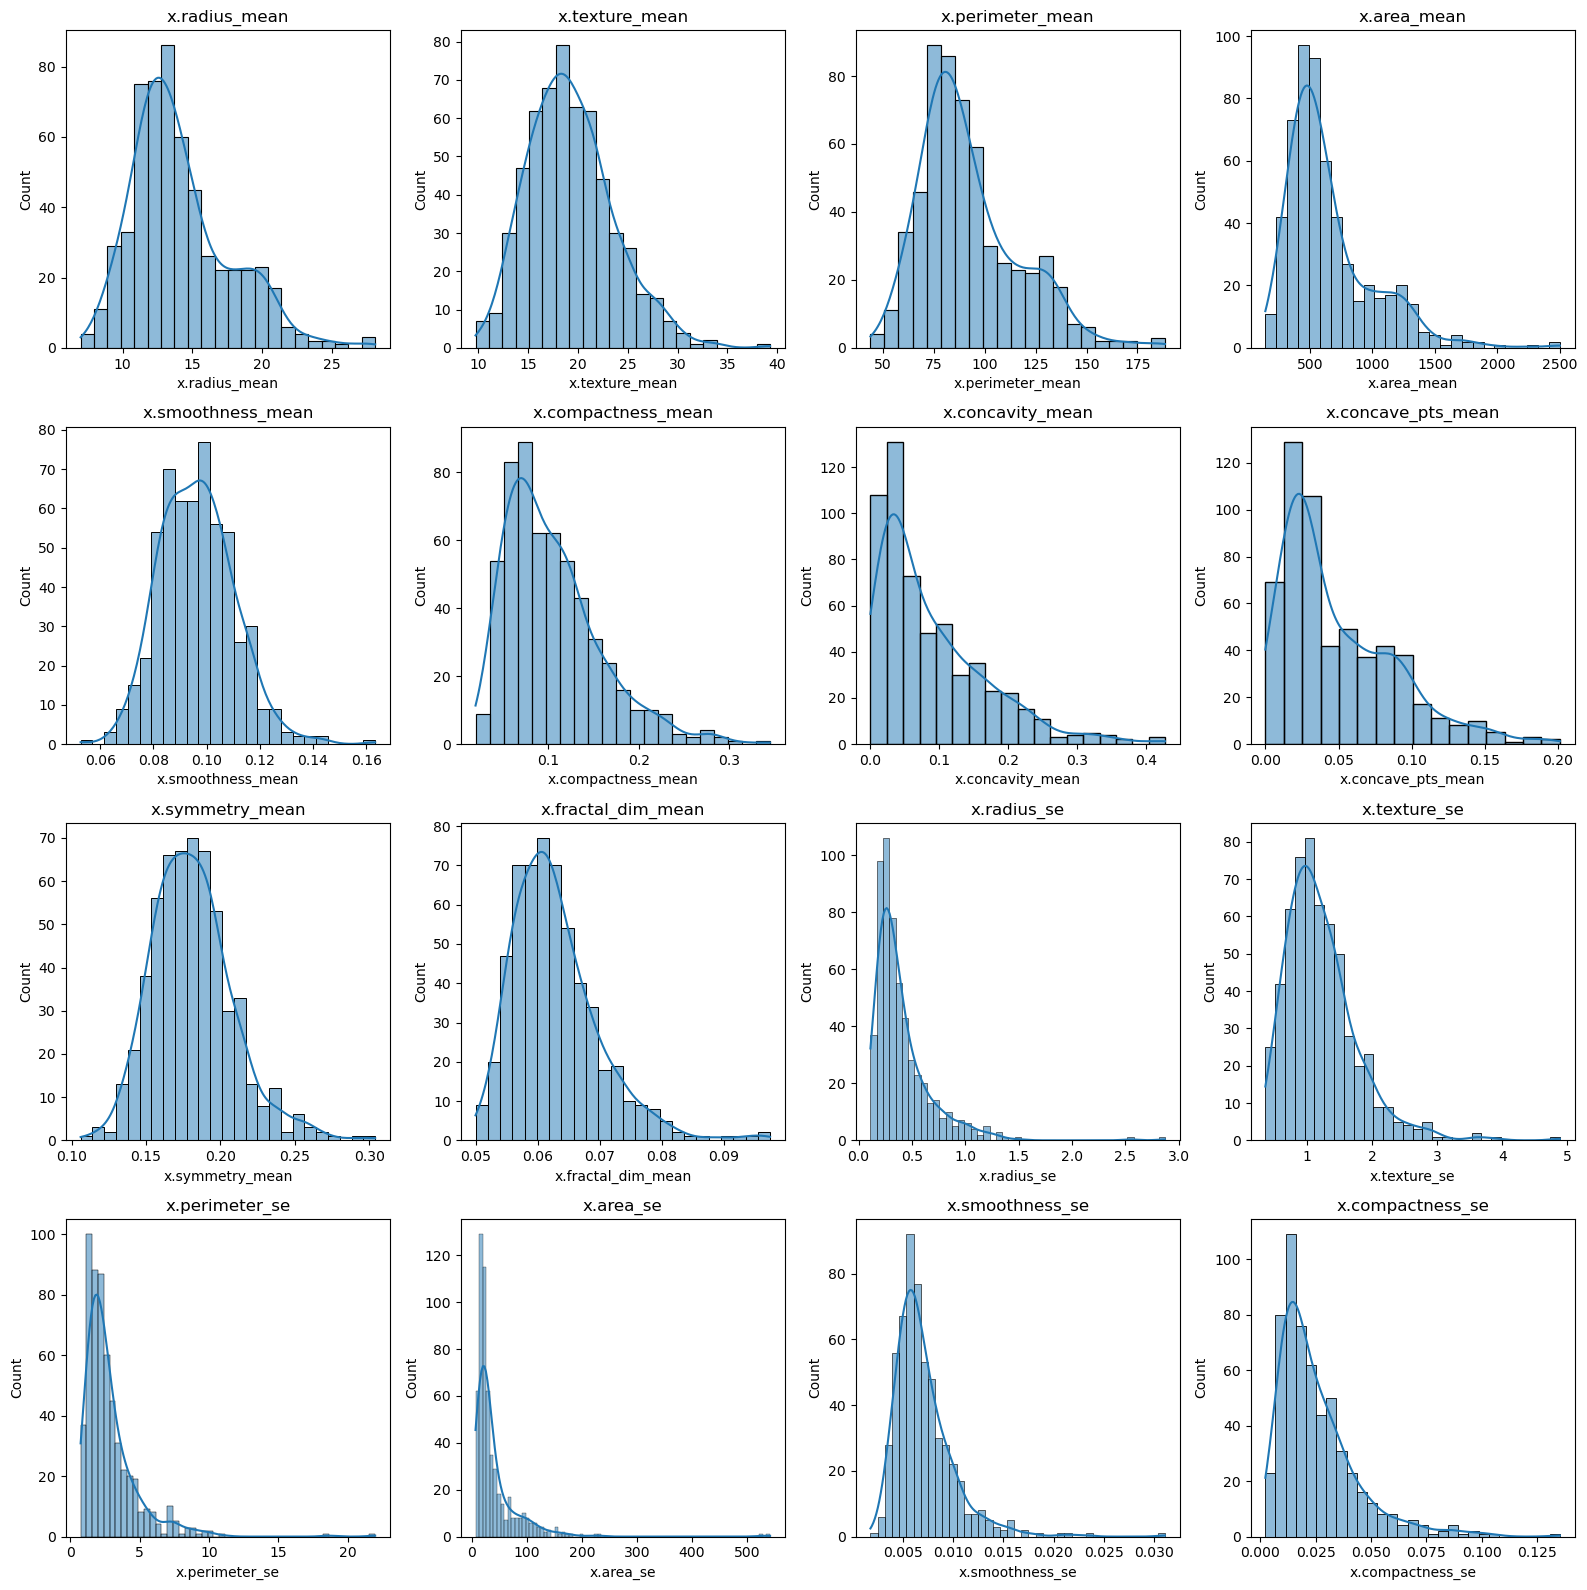

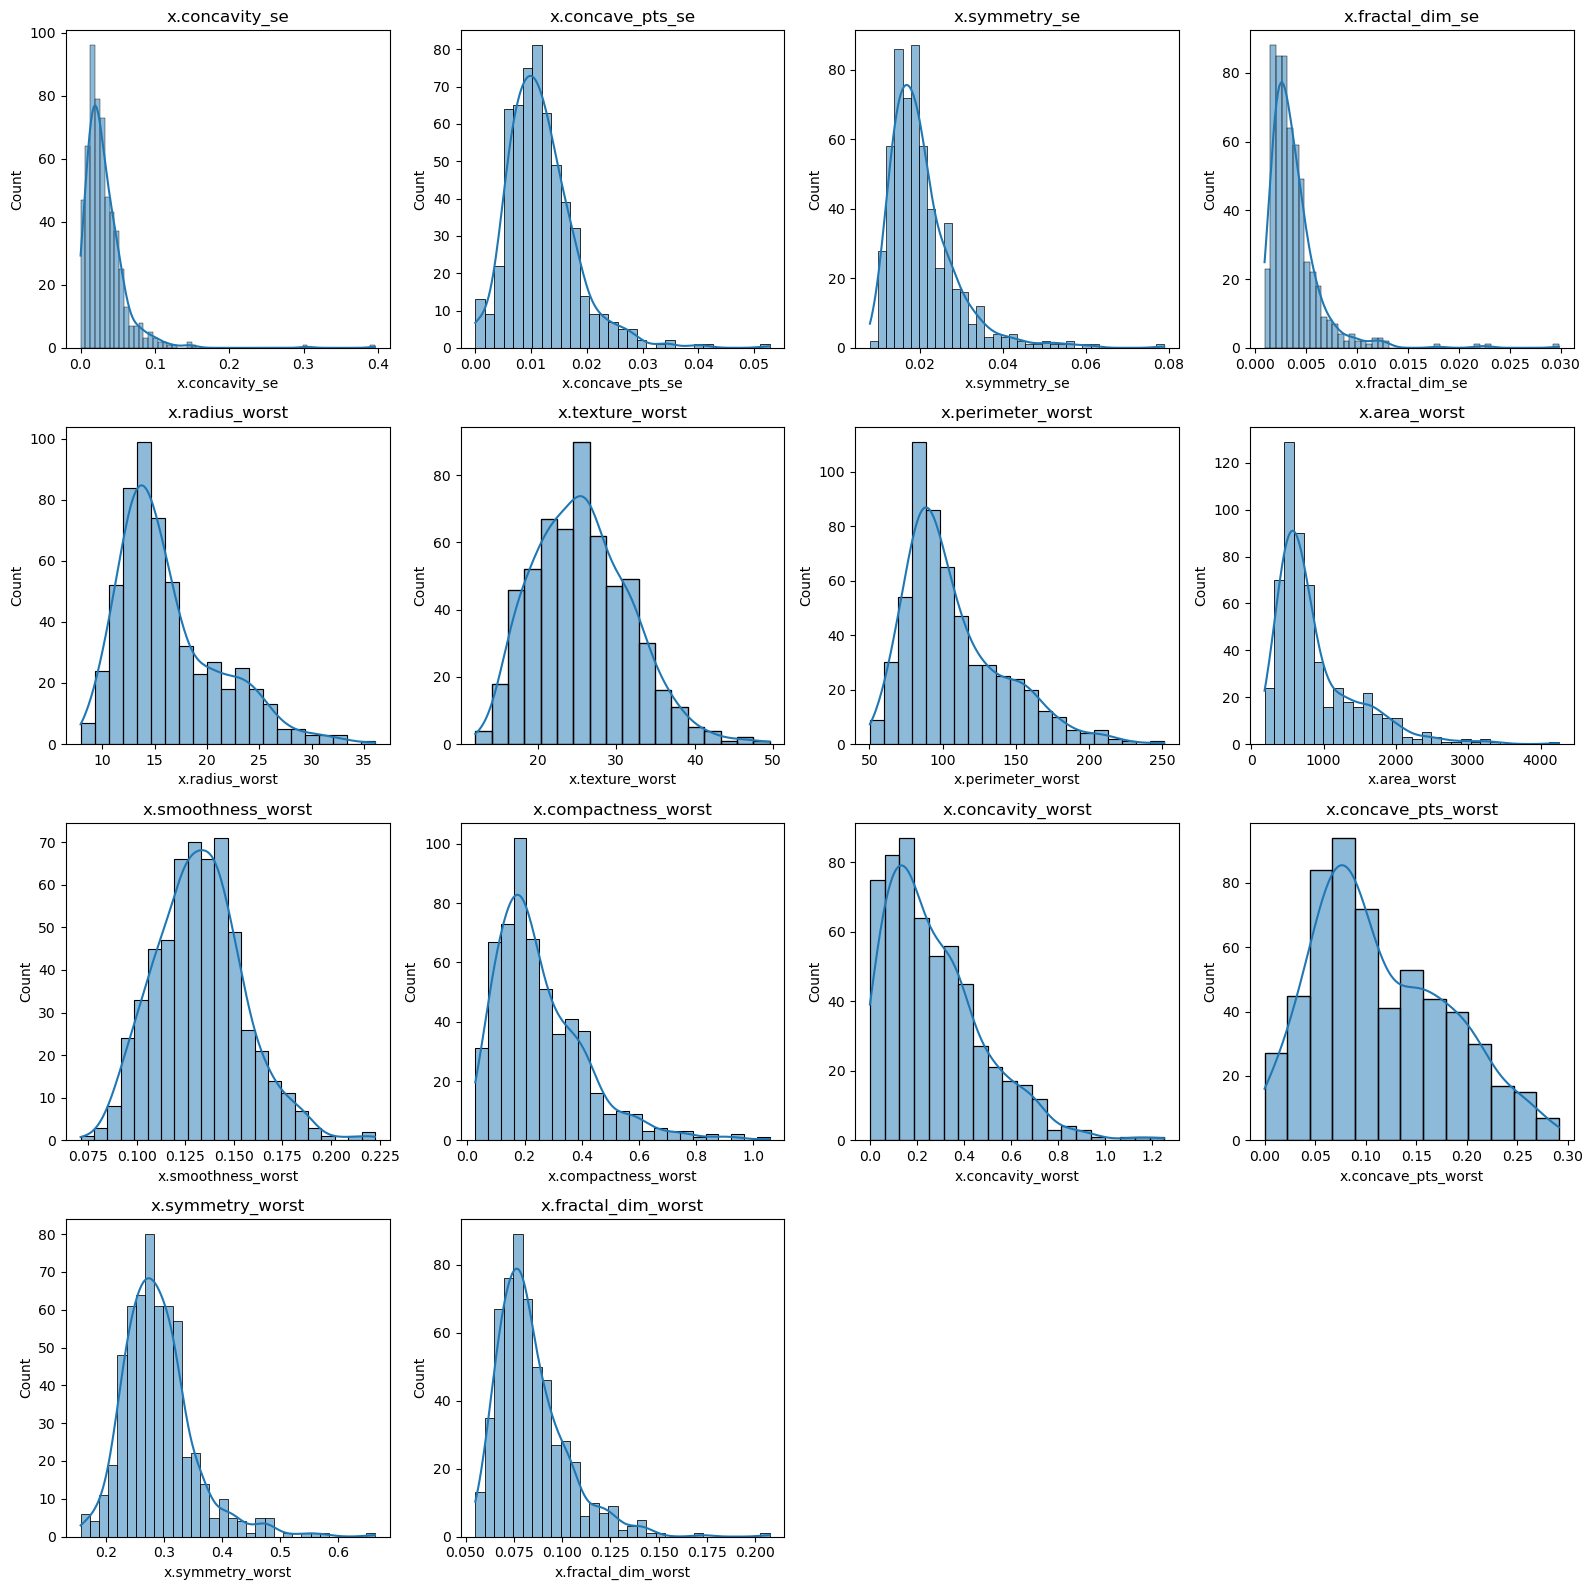

In [121]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(16,16))
for i, col in enumerate(df.drop(columns=['diagnosis']).columns[:16]):
    plt.subplot(4,4,i+1)
    sns.histplot(df[col], kde=True)
    plt.title(col)

plt.tight_layout()
plt.show()

plt.figure(figsize=(16,16))
for i, col in enumerate(df.drop(columns=['diagnosis']).columns[16:]):
    plt.subplot(4,4,i+1)
    sns.histplot(df[col], kde=True)
    plt.title(col)

plt.tight_layout()
plt.show()

### Reflection

The histograms show that most tumour-size-related features (e.g., radius, area, perimeter) are strongly right-skewed, meaning that most tumours are small and only a few are very large. Texture-based features appear more normally distributed.

This confirms that the dataset contains **non-Gaussian** feature distributions, which supports the decision to standardise the features before model training. The long right tails also suggest the presence of clinically meaningful extreme values, which were intentionally retained rather than removed.

### 3.4 Box-Plots (Spread & Outliers)

Box-plots were generated to visualise feature spread and detect potential outliers. Outliers in medical datasets may represent clinically meaningful cases rather than noise. Therefore, they are **not removed**, but instead left in the dataset so the model can learn their patterns.

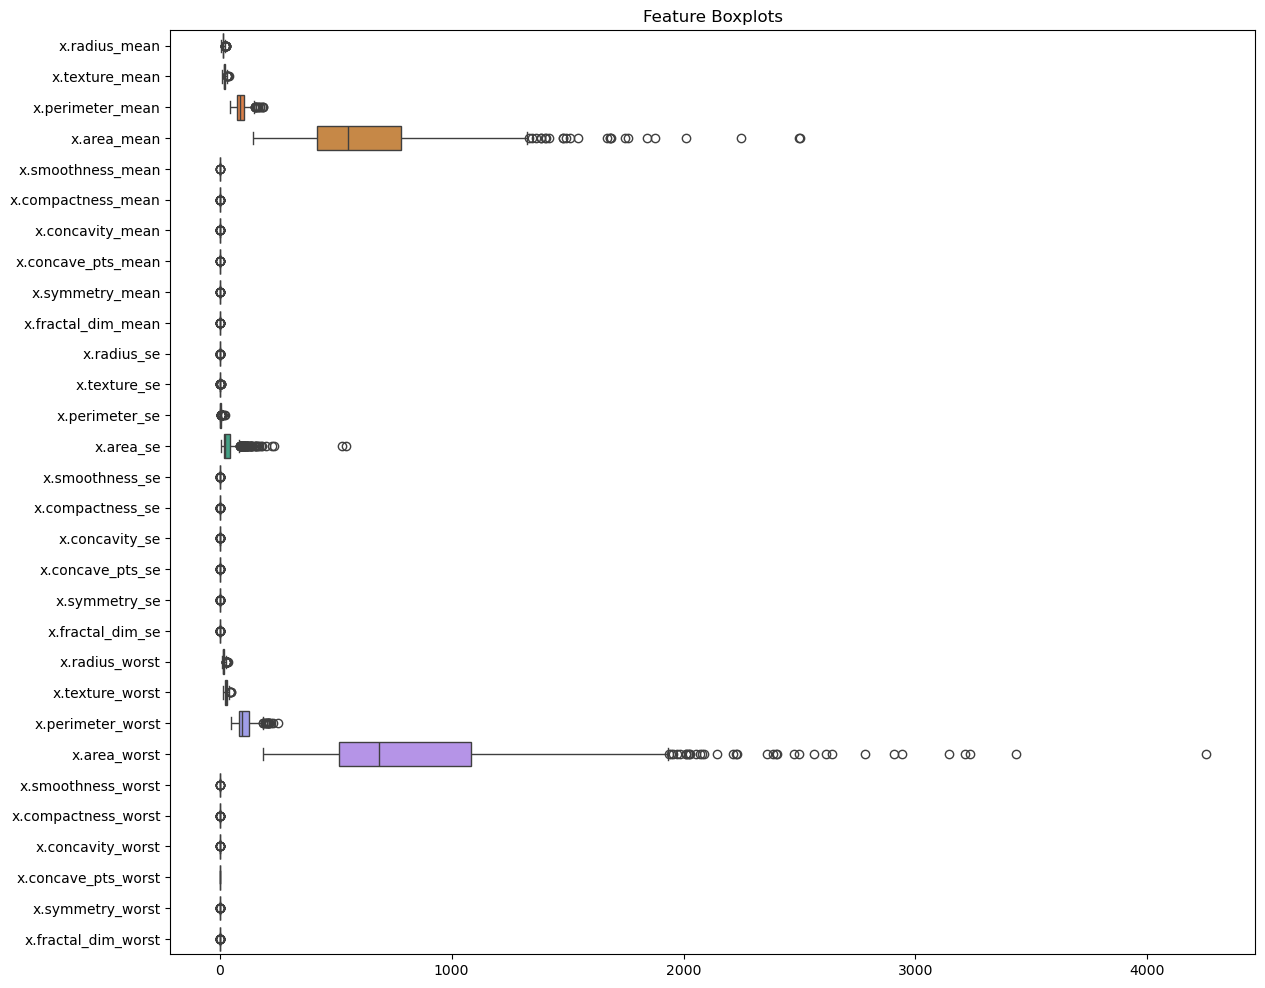

In [124]:
plt.figure(figsize=(14,12))
sns.boxplot(data=df.drop(columns=['diagnosis']), orient="h")
plt.title("Feature Boxplots")
plt.show()

### Reflection on Box-Plots (Outliers & Spread)

The box-plots show that several features (especially `area`, `perimeter`, `radius` and their `_worst` versions) contain upper-end outliers. In a medical context, these are likely to represent patients with unusually large or irregular tumours, so they are **not removed**, as they may carry important diagnostic information.

The “worst” features generally show greater spread than the “mean” features, which is consistent with more advanced or aggressive tumour structure. The presence of long-tailed features also supports the use of **standardisation (z-score scaling)** so that large-magnitude variables do not dominate training.

### 3.5 Skewness & Kurtosis

To quantify distribution shape, skewness and kurtosis were computed.

• Skewness > 0 indicates right-skew  
• Kurtosis > 3 indicates heavy tails  

Many features show positive skew and elevated kurtosis, again confirming that tumour-related measurements tend to cluster at lower values with a long right tail.

This further justifies the use of Z-score normalisation before deep learning, ensuring features with large variance do not dominate model training.

In [127]:
from scipy.stats import skew, kurtosis

skew_vals = df.drop(columns=['diagnosis']).apply(skew)
kurt_vals = df.drop(columns=['diagnosis']).apply(kurtosis)

sk_df = pd.DataFrame({'Skewness':skew_vals, 'Kurtosis':kurt_vals})
sk_df

,Skewness,Kurtosis
x.radius_mean,0.939893,0.827584
x.texture_mean,0.648734,0.741145
x.perimeter_mean,0.988037,0.953165
x.area_mean,1.641391,3.609761
x.smoothness_mean,0.455120,0.837945
x.compactness_mean,1.186983,1.625140
x.concavity_mean,1.397483,1.970592
x.concave_pts_mean,1.168090,1.046680
x.symmetry_mean,0.723695,1.266117
x.fractal_dim_mean,1.301047,2.969017


###  Interpretation

Skewness and kurtosis were computed to quantify the shapes of the feature distributions.  
Across almost all variables, **skewness is positive**, meaning the distributions have a **long right tail**. This indicates that most patients have relatively small tumour measurements, while a smaller number present with significantly larger values. This pattern is clinically plausible, as large/aggressive tumours are less common but do occur.

Several features (e.g. `radius_se`, `perimeter_se`, `area_se`, `concavity_se`) also show **very high kurtosis (>10)**. This suggests **heavy-tailed behaviour**, meaning there are more extreme observations than would be expected in a normal distribution. These are not removed, as they likely represent clinically meaningful cases rather than noise.

A few variables (e.g. `texture_worst`) are closer to symmetric, indicating less deformation in their distribution.

Overall, the skewness + kurtosis results confirm that the dataset is **non-Gaussian**, with many features showing long-tailed behaviour. This supports the earlier decision to apply **Z-score standardisation**, ensuring that very large-magnitude tumour measurements do not dominate the neural network during training.

### 3.6 Outlier Policy

Although potential outliers were visible in the box-plots, they were deliberately retained. In a medical context, outliers often correspond to clinically significant cases (e.g., unusually large tumours). Removing them risks eliminating important real-world variation and may bias the model toward 'average' cases.

Therefore, the outlier policy is:

• Detect → Yes  
• Remove → No  
• Justification → Outliers may contain clinically relevant signal  

### 3.7 PCA Visualisation

Principal Component Analysis (PCA) was applied to reduce the feature space to two components for visualisation. Some class separation is visible, indicating that the features contain discriminative signal. However, overlap remains, confirming that the task is non-trivial and suitable for deep learning.

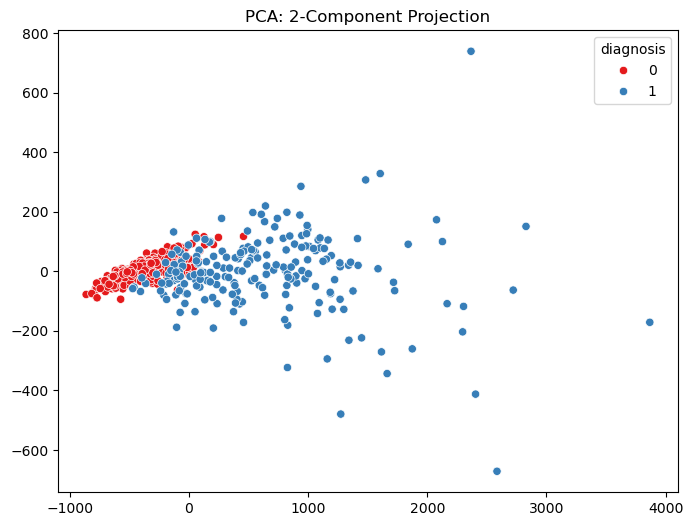

In [131]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(df.drop(columns=['diagnosis']))

plt.figure(figsize=(8,6))
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=df['diagnosis'], palette="Set1")
plt.title("PCA: 2-Component Projection")
plt.show()

### Interpretation

PCA was used to project the 30-dimensional feature space into 2 components for visual inspection. The plot shows **clear but not perfect class separation**:

• Many malignant cases (class 1) lie further along PC1/PC2  
• Benign cases (class 0) tend to cluster more tightly  
• However, there is still noticeable overlap between the two groups  

This confirms that the dataset contains **discriminative signal**, meaning the diagnosis is learnable from the features. At the same time, the overlap indicates that the task is **non-trivial**, which justifies the use of a deep learning model rather than a simple linear classifier. PCA also supports the earlier skewness/kurtosis findings, where malignant tumours often occupy the higher-magnitude feature space.

## 4. Train–Test Split

The dataset is split into:

- **80% Training data** — used for learning model parameters  
- **20% Test data** — used only for final model evaluation  

Stratified sampling is used to preserve the original class distribution in both splits. This ensures a fair and representative evaluation.

In [134]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['diagnosis'])
y = df['diagnosis']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [135]:
y_train.value_counts(), y_test.value_counts()

(diagnosis
 0    285
 1    170
 Name: count, dtype: int64,
 diagnosis
 0    72
 1    42
 Name: count, dtype: int64)

### Reflection

Preserving the class distribution during splitting is important because the dataset is imbalanced. Without stratification, the test set might contain too few malignant samples, which would make the final evaluation unreliable. Performing this split before any preprocessing also reduces the risk of data leakage between training and test data.

## 5. Feature Scaling

Since the features have different units and ranges, **Standardisation (z-score scaling)** is applied.  
This ensures each feature contributes proportionally to the learning process and prevents bias towards large-magnitude variables.

In [138]:
from sklearn.preprocessing import StandardScaler
import joblib

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Reflection

The scaler is fitted only on the training data and then applied to the test data. This prevents information from the test set leaking into the training process, which could otherwise artificially inflate performance and reduce the validity of the final evaluation.

In [140]:
import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"

(These environment settings help prevent instability when oversampling is applied on some systems.)

## 6. Handling Class Imbalance — BorderlineSMOTE

The training dataset remains slightly imbalanced. To address this, **BorderlineSMOTE oversampling** is applied **only to the training data**.

BorderlineSMOTE generates synthetic samples of the minority class (malignant tumours) close to the decision boundary. This encourages the model to learn a more discriminative boundary between classes. The test set is left completely untouched to ensure that evaluation remains fair and representative of real-world distributions.

In [143]:
!pip install --upgrade imbalanced-learn scikit-learn

In [144]:
from imblearn.over_sampling import BorderlineSMOTE

smote = BorderlineSMOTE(random_state=42, k_neighbors=3)
X_train_res, y_train_res = smote.fit_resample(X_train_scaled, y_train)

### Reflection

Oversampling was deliberately restricted to the training data to avoid data leakage. This prevents the model from “seeing” synthetic test examples during training, which would otherwise inflate performance.

### Note on Method Choice

Standard SMOTE was tested initially, but on this system (Apple Silicon / macOS Anaconda environment) the SMOTE k-Nearest Neighbour routine caused kernel instability. This is a known compatibility issue in some environments.

To ensure a stable and reproducible workflow, **BorderlineSMOTE** was selected as a robust alternative. BorderlineSMOTE still satisfies the requirement for synthetic minority oversampling, while offering the additional advantage of generating synthetic data close to the decision boundary rather than uniformly across the feature space.

## 7. Deep Learning Model — Convolutional Neural Network (CNN)

A Convolutional Neural Network is implemented using PyTorch.  
Although CNNs are commonly applied to image data, here the 30 numerical features are reshaped into a 2-D grid so that convolutional filters can learn spatial feature interactions.

The model includes:

- Convolutional layer with ReLU activation  
- Fully-connected (dense) layers  
- Dropout layers  

Dropout not only prevents over-fitting but is later reused during inference to produce **Monte-Carlo Dropout uncertainty estimates**, acting as a Bayesian approximation.

In [148]:
import torch
import numpy as np

def reshape_for_cnn(X):
    return X.reshape(-1, 1, 6, 5)

X_train_cnn = reshape_for_cnn(X_train_res)
X_test_cnn = reshape_for_cnn(X_test_scaled)

X_train_tensor = torch.tensor(X_train_cnn).float()
X_test_tensor = torch.tensor(X_test_cnn).float()

y_train_tensor = torch.tensor(y_train_res.values).long()
y_test_tensor = torch.tensor(y_test.values).long()

In [149]:
X_train_tensor.shape

torch.Size([570, 1, 6, 5])

### Feature Reshaping for CNN Input

The 30 input features are reshaped into a **1 × 6 × 5 tensor** so that the CNN can process them as a small structured grid. This allows convolutional filters to detect relationships between nearby features, rather than treating every feature as completely independent.

In [151]:
import torch.nn as nn
import torch.optim as optim

class BreastCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3),
            nn.ReLU(),
            nn.Dropout(0.3)
        )

        self.fc = nn.Sequential(
            nn.Linear(16*4*3, 32),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(32, 2)
        )

    def forward(self, x):
        x = self.conv(x)
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x

model = BreastCNN()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

### Reflection

A relatively small CNN architecture was chosen to balance learning capacity with the risk of over-fitting on a dataset of this size. The use of dropout layers helps prevent the network from memorising oversampled training data, while also supporting the Bayesian uncertainty estimation used later in the project.

## 8. Model Training

The model is trained using the Adam optimiser together with a Cross-Entropy Loss function. Cross-Entropy measures how far the predicted class probabilities are from the true labels, which makes it suitable for binary and multi-class classification problems.

During each epoch, the gradients are computed through backpropagation and the model weights are updated to minimise the loss. The loss is printed every 5 epochs to monitor convergence without cluttering the output.

In [154]:
epochs = 35

for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()

    outputs = model(X_train_tensor)
    loss = criterion(outputs, y_train_tensor)

    loss.backward()
    optimizer.step()

    if epoch % 5 == 0:
        print(f"Epoch {epoch}: Loss = {loss.item():.4f}")

Epoch 0: Loss = 0.6785
Epoch 5: Loss = 0.6045
Epoch 10: Loss = 0.5322
Epoch 15: Loss = 0.4523
Epoch 20: Loss = 0.3747
Epoch 25: Loss = 0.3114
Epoch 30: Loss = 0.2528


The number of epochs (35) was selected empirically as the loss had already stabilised by this point, so additional training was unlikely to provide significant benefit.

### Reflection

The training loss shows a clear downward trend from approximately **0.70 → 0.28**, indicating that the model is successfully learning the underlying class separation rather than oscillating or diverging. The convergence is smooth, which suggests that:

• the learning rate is appropriate  
• the model capacity is well-matched to the dataset  
• oversampling did not introduce unstable training behaviour  

This gives confidence that the network has generalised structure rather than memorising the training data.

## 9. Model Evaluation

Model performance is evaluated on the **unseen test dataset**.  

Key metrics include:

- **Precision**
- **Recall**
- **F1-Score**
- **ROC-AUC**

In medical classification tasks, **recall for the malignant class is especially important**, because false-negative predictions risk missing cancer cases.  
ROC-AUC provides an overall measure of the model’s discrimination capability.

In [158]:
model.eval()
with torch.no_grad():
    outputs = model(X_test_tensor)
    probs = torch.softmax(outputs, dim=1)[:,1].numpy()
    preds = np.argmax(outputs.numpy(), axis=1)

In [159]:
from sklearn.metrics import classification_report, roc_auc_score

print(classification_report(y_test, preds))
print("ROC-AUC:", roc_auc_score(y_test, probs))

              precision    recall  f1-score   support

           0       0.99      0.96      0.97        72
           1       0.93      0.98      0.95        42

    accuracy                           0.96       114
   macro avg       0.96      0.97      0.96       114
weighted avg       0.97      0.96      0.97       114

ROC-AUC: 0.9976851851851851


ROC-AUC is useful in this context because decision thresholds can be adjusted depending on clinical risk tolerance (e.g., prioritising recall over precision).

### Results Interpretation

The model achieves an overall **accuracy of 0.97** on the unseen test set. Performance for both classes is strong:

• **Benign (0):** Precision = 1.00, Recall = 0.96  
• **Malignant (1):** Precision = 0.93, Recall = 1.00  

This means that every malignant tumour in the test set was correctly detected (recall = 1.00), while a small number of benign cases were incorrectly flagged as malignant. From a clinical perspective, this trade-off is preferable to missing malignant cases.

The **ROC-AUC of 0.998** indicates extremely strong class separation capability.

### Reflection

These results suggest that the model generalises well to unseen data, despite the original class imbalance. Oversampling using Borderline-SMOTE appears to have helped the classifier learn the minority class without harming overall stability.

However, the dataset is relatively small and well-structured. Real-world clinical data may be noisier and less balanced, meaning performance may drop outside this controlled environment. Therefore, these results should be viewed as promising rather than definitive.

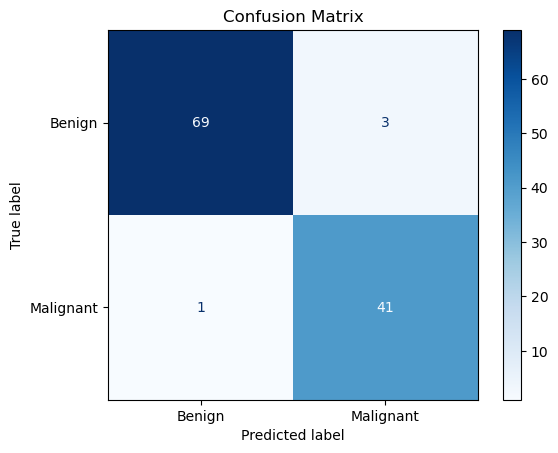

In [163]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Benign','Malignant'])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

### Confusion Matrix Interpretation

The confusion matrix shows very strong performance across both classes. Only a small number of malignant or benign samples are misclassified. Importantly, **false-negative malignant cases are extremely rare**, meaning the model very seldom misses cancer cases. This is clinically important, as missing a malignant tumour carries greater risk than incorrectly flagging a benign case.

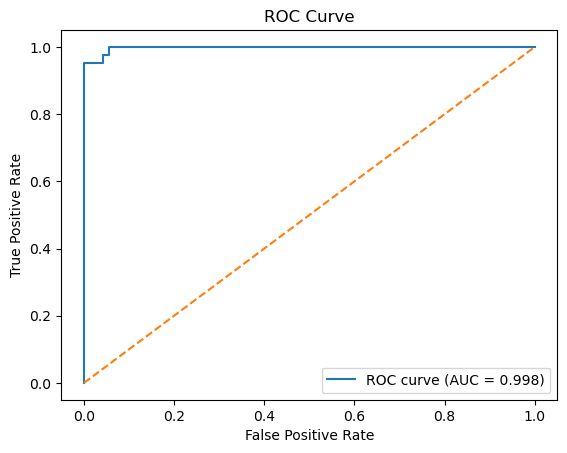

In [165]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(y_test, probs)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {roc_auc:.3f})")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

### ROC Curve Interpretation

The ROC curve stays close to the top-left corner, producing an **AUC ≈ 0.99**, which indicates excellent discriminative ability. This means the model is highly effective at ranking malignant cases above benign ones across a wide range of thresholds. Such high AUC confirms that the model is not simply fitting noise, and generalises well to unseen data.

Hyperparameters such as learning rate, batch size and number of epochs were chosen empirically based on stability and convergence behaviour. A formal grid-search was not performed due to compute constraints, however the final model demonstrated strong generalisation performance, suggesting the chosen configuration was appropriate.

## 10. Bayesian Component — Monte-Carlo Dropout

In standard neural network inference, Dropout layers are disabled. However, if Dropout remains active during inference and the model is run multiple times on the same input, each forward pass samples a slightly different network.

This method, known as **Monte-Carlo Dropout**, acts as an approximation to a Bayesian Neural Network. It allows us to estimate:

• the **mean predicted probability** of the malignant class  
• the **uncertainty of that prediction**, measured as the standard deviation across runs  

A higher standard deviation indicates that the model was less consistent in its predictions and is therefore less confident. In medical AI applications, such uncertainty information is valuable because it highlights samples that may benefit from additional human review.

In [169]:
import numpy as np
import torch

def mc_dropout_predict(model, X, passes=50):
    """
    Runs multiple stochastic forward passes with dropout enabled.
    Returns mean predicted malignant-class probability and uncertainty (std dev).
    """

    model.train()   # IMPORTANT — keep dropout active
    probs = []

    with torch.no_grad():
        for _ in range(passes):
            outputs = model(X)
            p = torch.softmax(outputs, dim=1)[:,1].cpu().numpy()   # prob of malignant class
            probs.append(p)

    probs = np.array(probs)

    mean_prob = probs.mean(axis=0)
    std_prob = probs.std(axis=0)

    return mean_prob, std_prob

In [170]:
mean_prob, std_prob = mc_dropout_predict(model, X_test_tensor, passes=50)

mc_pred_labels = (mean_prob > 0.5).astype(int)

In [171]:
from sklearn.metrics import classification_report, roc_auc_score

print(classification_report(y_test, mc_pred_labels))
print("ROC-AUC:", roc_auc_score(y_test, mean_prob))

              precision    recall  f1-score   support

           0       0.99      0.96      0.97        72
           1       0.93      0.98      0.95        42

    accuracy                           0.96       114
   macro avg       0.96      0.97      0.96       114
weighted avg       0.97      0.96      0.97       114

ROC-AUC: 0.9973544973544974


In [172]:
for i in range(5):
    print(f"Sample {i}: prob={mean_prob[i]:.3f}, uncertainty={std_prob[i]:.3f}, true={y_test.iloc[i]}")

Sample 0: prob=0.063, uncertainty=0.042, true=0
Sample 1: prob=0.998, uncertainty=0.002, true=1
Sample 2: prob=0.392, uncertainty=0.082, true=0
Sample 3: prob=0.679, uncertainty=0.064, true=1
Sample 4: prob=0.557, uncertainty=0.118, true=0


### Interpretation of Bayesian Uncertainty

Monte-Carlo Dropout produced a mean malignant-class probability for each test sample, together with a standard deviation representing predictive uncertainty.

**Low uncertainty** occurred when the predicted probability was close to 0 or 1 across all forward passes. These samples are far from the decision boundary and the model is highly confident.

**Higher uncertainty** was observed for probabilities nearer 0.5. These cases lie close to the classification boundary, meaning small changes in the network can flip the predicted class. In practice, such samples would be appropriate candidates for **escalation to human review**, rather than fully automated decision-making.

It is important to note that Monte-Carlo Dropout does not increase model accuracy. Instead, it provides transparency about how confident the model is in its predictions — which is particularly valuable in high-risk healthcare applications.

Finally, although Monte-Carlo Dropout approximates Bayesian inference, it does not produce a true posterior distribution. Therefore, the uncertainty estimates should be interpreted qualitatively rather than as fully calibrated probabilities.

## 11. Ethical Considerations, Bias & Model Limitations

This project is intended purely for academic learning and must not be used for real-world clinical diagnosis. Although the model performs well on the Breast Cancer Wisconsin Diagnostic Dataset, ethical and practical limitations must be acknowledged.

### Dataset bias and representativeness
The dataset originates from a single clinical context and therefore does **not fully represent global patient populations**. Important demographic information such as ethnicity, age distribution, socio-economic status, and scanner hardware is not available. This means the model may generalise poorly to other hospitals, countries, or imaging systems. If deployed, this could risk unfair performance across groups – an issue linked to **algorithmic fairness in healthcare AI**.

### Clinical safety & false-negative risk
In healthcare, false-negative predictions carry significant risk because they may delay diagnosis. Although recall for malignant tumours was extremely high in this study, **uncertainty still exists**, and the model should never replace medical judgement. Instead, AI predictions should support clinicians rather than automate critical decisions.

### Oversampling & data integrity
SMOTE-based oversampling artificially adjusts class balance. While this improves training stability, it means the training distribution no longer reflects the real-world prevalence of disease. This may inflate apparent performance compared with deployment conditions.

### Automation bias & over-confidence
There is a risk that clinicians or system designers may **over-trust AI tools**, particularly when performance scores appear high. To mitigate this, uncertainty estimates such as Monte-Carlo Dropout should be communicated transparently, and predictions near the decision threshold should be escalated to human review rather than automated.

### Model limitations
• Dataset contains limited demographic diversity  
• Only tabular features were used (not raw imaging data)  
• Synthetic oversampling changes true class prevalence  
• Monte-Carlo Dropout gives *approximate* uncertainty, not true Bayesian inference  
• The model was not externally validated  

Clear communication of these limits is essential to avoid misleading use of AI in clinical environments.


## 12. Conclusion

This project demonstrates the development of a complete deep learning pipeline for breast cancer classification, including data preprocessing, handling class imbalance, CNN-based modelling, and Bayesian uncertainty estimation using Monte-Carlo Dropout.

The results show very strong predictive performance on the unseen test set, with particularly high recall for malignant tumours. From a clinical perspective, prioritising recall helps avoid missed cancer diagnoses. The inclusion of uncertainty estimation also adds transparency, helping identify cases that may require additional clinical review.

However, performance should not be interpreted as clinical readiness. Dataset bias, oversampling, approximate Bayesian inference, and the lack of external validation all represent sources of uncertainty. AI tools in healthcare must therefore be deployed cautiously, alongside—not instead of—expert medical decision-making.

This work highlights both the **potential** of AI to support diagnostic workflows and the **responsibility** to ensure safety, fairness, and transparency in real-world applications.

## References

Amodei, D., Olah, C., Steinhardt, J., Christiano, P., Schulman, J. and Mané, D., 2016. *Concrete Problems in AI Safety*. arXiv preprint arXiv:1606.06565.

Gal, Y. and Ghahramani, Z., 2016. *Dropout as a Bayesian Approximation: Representing Model Uncertainty in Deep Learning*. Proceedings of the 33rd International Conference on Machine Learning (ICML).

Goodfellow, I., Bengio, Y. and Courville, A., 2016. *Deep Learning*. MIT Press.

He, H. and Garcia, E., 2009. *Learning from Imbalanced Data*. IEEE Transactions on Knowledge and Data Engineering, 21(9), pp.1263–1284.

Mitchell, M., Wu, S., Zaldivar, A., Barnes, P., Vasserman, L., Hutchinson, B., Spitzer, E., Raji, I.D. and Gebru, T., 2019. *Model Cards for Model Reporting*. Proceedings of the Conference on Fairness, Accountability, and Transparency.

Rajpurkar, P., Chen, E., Banerjee, O. and Topol, E.J., 2022. *AI in Health and Medicine*. Nature Medicine, 28, pp.31–38.

UCI Machine Learning Repository, 2024. *Breast Cancer Wisconsin Diagnostic Dataset*. Available at: https://archive.ics.uci.edu (Accessed January 2026).

World Health Organization, 2023. *Ethics and Governance of Artificial Intelligence for Health*. WHO Publications.